In [1]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt
from pansharpening import PANDataset
from alg3 import PANTVCtv
from torchvision import transforms
from math import sqrt

/home/ndiayem/Documents/spectral-spatial/env/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
# Define device (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64
crop_size = 256
    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '/home/ndiayem/Documents/spectral-spatial/data/harvard.zarr'

In [3]:
val_transform  =  transforms.Compose([ transforms.CenterCrop(crop_size)])
dataset =PANDataset(root_dir=data_path, split='train' ,transform=val_transform ,normalize=True,scale=2,sigma=0.1,device=device,size=crop_size)

In [4]:
idx = 17
X = dataset[idx]
X = X.unsqueeze(0)

In [5]:
# Matrice de transformation
Y_H = dataset.simule_low_res_hsi(X)  
Y_M = dataset.get_panchromatic(X)

In [26]:
A,A_adj, R, R_adj = dataset.get_operators()

solver_gp = PANTVCtv(
    A=A,
    Aadj=A_adj,
    spectral_op = dataset.spectral_op,
    spectral_op_t = dataset.spectral_op_t,
    max_iter=2000,
    lmbda=1e-2,
    lmbda_m=5,
    tol=1e-7,
    scale=dataset.scale,
    p = 2,
    q = 2,
    r = 1,
    verbose=True,
    
)

In [27]:
U_gp, costs_gp = solver_gp(Y_H, Y_M)


Début de l'optimisation:
It    | Coût total   | Data H       | Data M       | TV           | ΔU          
--------------------------------------------------------------------------------
0     | 4.558e+03    | 3.099e+03    | 1.454e+03    | 5.620e+00    | 9.373e-03   
10    | 4.286e+03    | 2.921e+03    | 1.359e+03    | 6.313e+00    | 8.272e-03   
20    | 4.032e+03    | 2.755e+03    | 1.270e+03    | 7.082e+00    | 7.370e-03   
30    | 3.796e+03    | 2.599e+03    | 1.188e+03    | 7.874e+00    | 6.618e-03   
40    | 3.575e+03    | 2.454e+03    | 1.112e+03    | 8.668e+00    | 5.984e-03   
50    | 3.370e+03    | 2.319e+03    | 1.042e+03    | 9.455e+00    | 5.442e-03   
60    | 3.178e+03    | 2.192e+03    | 9.762e+02    | 1.023e+01    | 4.973e-03   
70    | 2.999e+03    | 2.073e+03    | 9.153e+02    | 1.099e+01    | 4.565e-03   
80    | 2.833e+03    | 1.962e+03    | 8.588e+02    | 1.174e+01    | 4.207e-03   
90    | 2.677e+03    | 1.858e+03    | 8.062e+02    | 1.247e+01    | 3.890e-03   
10

In [28]:
U_gp.shape

torch.Size([1, 31, 256, 256])

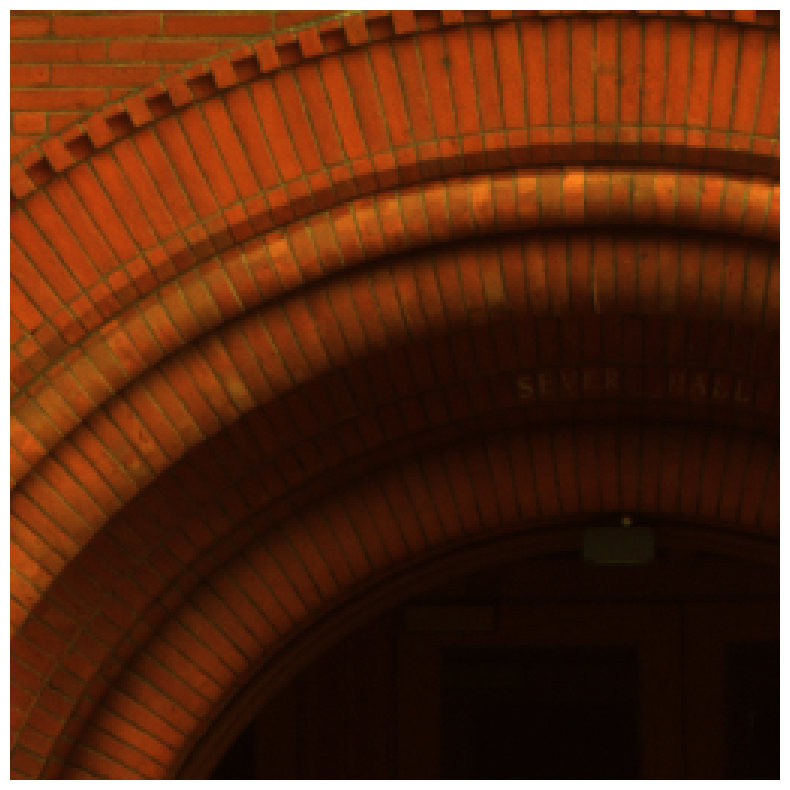

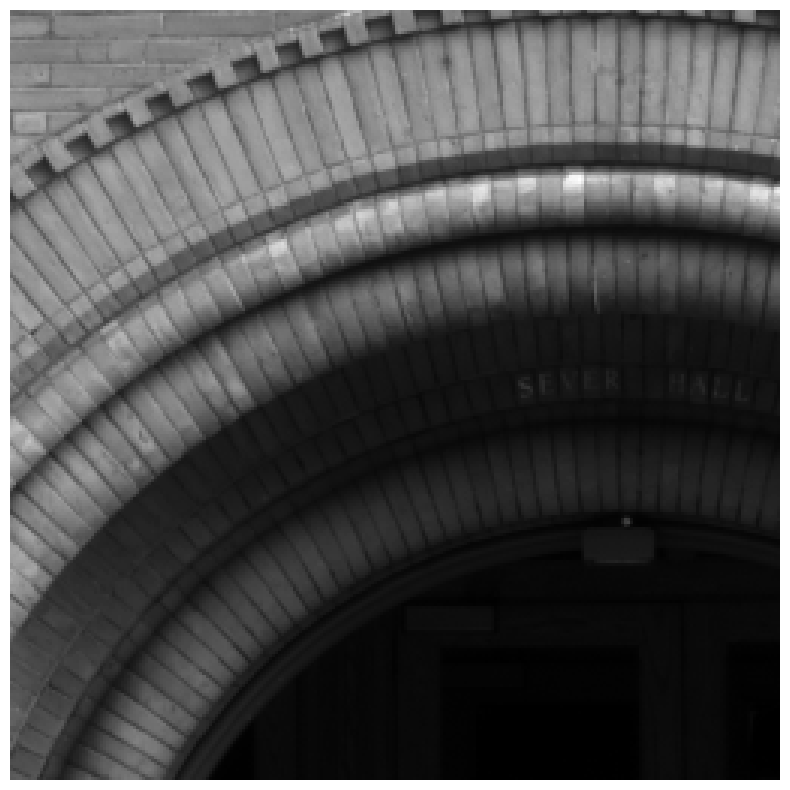

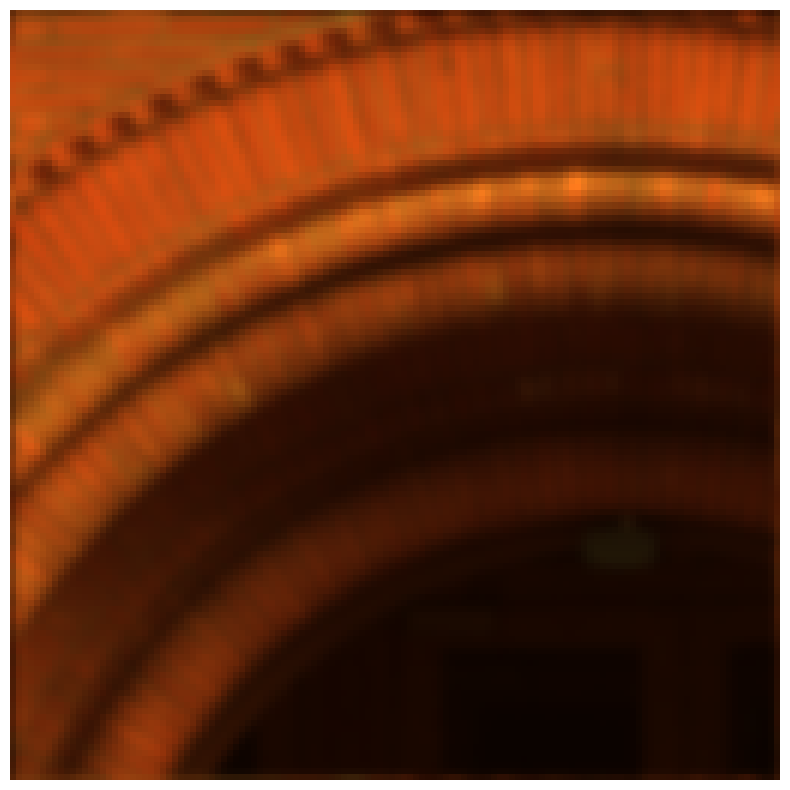

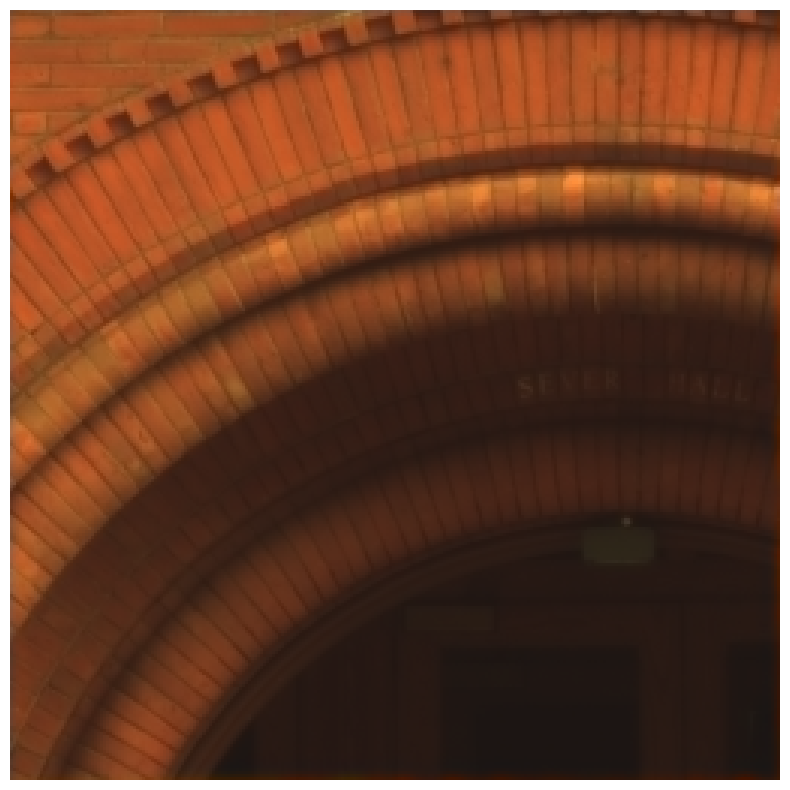

In [29]:
rgb = dataset.rgb_index
x_rgb = X[0, rgb,...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

y_rgb = Y_H[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
y_rgb = (y_rgb - y_rgb.min())/(y_rgb.max() - y_rgb.min())

z_rgb = U_gp[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())

# plt.figure(figsize=(15, 5))
# plt.subplot(131)
plt.figure(figsize=(10,10))
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')

# plt.subplot(132)
plt.figure(figsize=(10,10))
plt.imshow(Y_M[0, 0, ...].cpu().numpy(), cmap='gray')
# plt.title('Panchromatic')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(y_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(z_rgb)
# plt.title('Noisy RGB')=4
plt.axis('off')

plt.show()

Dimensions vérifiées: iterations (2000,), cout_total 2000


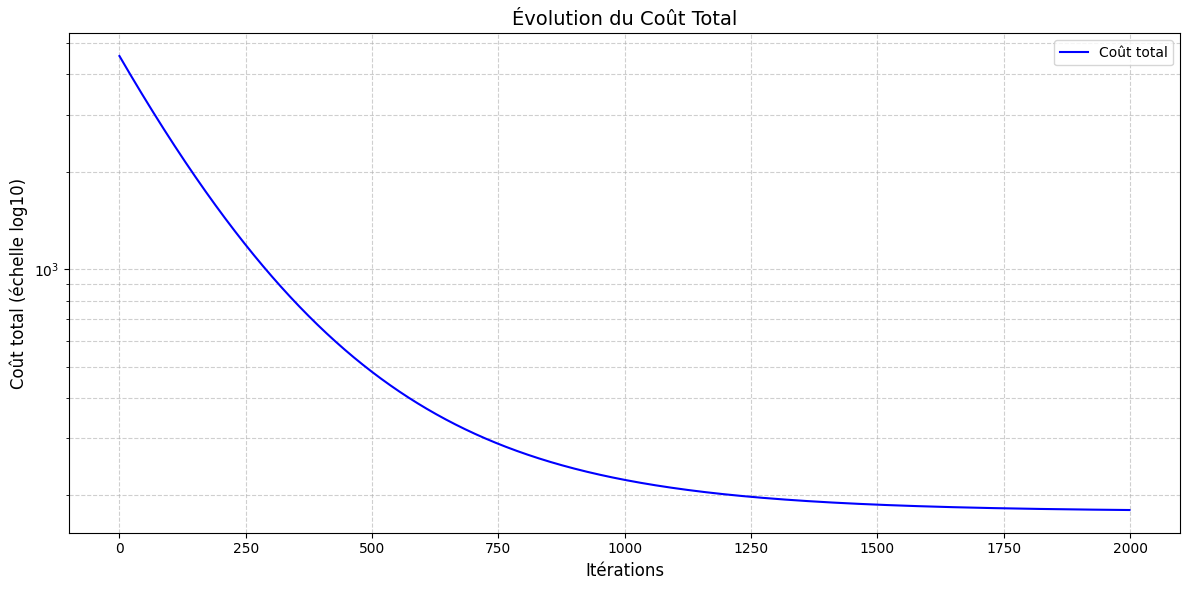

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Données d'exemple (à adapter avec vos données réelles)
cout_total = costs_gp

# Création du vecteur d'itérations de même longueur que cout_total
iterations = np.arange(0, len(cout_total))  # Pas de 10 entre les mesures

# Vérification des dimensions
print(f"Dimensions vérifiées: iterations {iterations.shape}, cout_total {len(cout_total)}")

# Création du graphique
plt.figure(figsize=(12, 6))
plt.semilogy(iterations, cout_total, 'b-', linewidth=1.5, label='Coût total')

# Personnalisation
plt.xlabel('Itérations', fontsize=12)
plt.ylabel('Coût total (échelle log10)', fontsize=12)
plt.title('Évolution du Coût Total', fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.6)

# Affichage
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
import torch
from torchvision import transforms
from PIL import Image
to_pil = transforms.ToPILImage()

In [32]:
image1 = to_pil(x_rgb)
image1.save('image1.png')

In [33]:
image2 = to_pil(Y_M[0, 0, ...])
image2.save('image2.png')

In [34]:
image3 = to_pil(y_rgb)
image3.save('image3.png')

In [35]:
image4 = to_pil(z_rgb)
image4.save('image4.png')